# Senario Generation (2025 Baseline vs Renewable Upside)

This notebook generates three senarios from 2025 actual data:

1. baseline: uses 2025 NET_LOAD actuals
2. senario_A: 1.5x solar, 1.0x wind
3. senario_B: 2.0x solar, 1.1x wind

Assumption: ERCOT.LOAD stays at 2025 actual values; only renewable generation is scaled.

In [ ]:
# Kernel Management Cell
# Run this cell to install/upgrade packages and restart the kernel

# Step 1: Install/upgrade required packages
""" import sys
import subprocess

print("Installing required packages...")
subprocess.check_call([
    sys.executable, "-m", "pip", "install", 
    "--trusted-host", "pypi.org", 
    "--trusted-host", "files.pythonhosted.org",
    "--upgrade", "plotly", "kaleido"
])
print("Packages installed successfully!")
print("\n" + "="*60)
print("IMPORTANT: Now restart the kernel using your IDE:")
print("  - VS Code: Click 'Restart' button in notebook toolbar")
print("  - JupyterLab: Kernel menu -> Restart Kernel")
print("="*60)
 """
# Step 2: After restart, uncomment these lines to enable autoreload:
# %load_ext autoreload
# %autoreload 2
# print("Autoreload enabled - modules will be reloaded automatically")

Installing required packages...
Packages installed successfully!

IMPORTANT: Now restart the kernel using your IDE:
  - VS Code: Click 'Restart' button in notebook toolbar
  - JupyterLab: Kernel menu -> Restart Kernel


In [1]:
from pathlib import Path
import pandas as pd
from pathlib import Path
import sys

ROOT = Path('C:/Renewable-PowerGrid-Risk')
# Adds src to sys.path
src_path = ROOT / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
print(sys.path)


from metrics import compute_risk_metrics


ROOT = Path('C:/Renewable-PowerGrid-Risk')
SENARIO_DIR = ROOT / 'data' / 'senarios'
input_path = ROOT / 'data' / 'processed' / 'hourly_load_renewable_merged.csv'

df = pd.read_csv(input_path, parse_dates=['datetime'])
print(f'Loaded: {input_path}')
print(df.shape)

['C:\\Renewable-PowerGrid-Risk\\src', 'c:\\Users\\kylez\\AppData\\Local\\Python\\pythoncore-3.14-64\\python314.zip', 'c:\\Users\\kylez\\AppData\\Local\\Python\\pythoncore-3.14-64\\DLLs', 'c:\\Users\\kylez\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib', 'c:\\Users\\kylez\\AppData\\Local\\Python\\pythoncore-3.14-64', '', 'C:\\Users\\kylez\\AppData\\Roaming\\Python\\Python314\\site-packages', 'c:\\Users\\kylez\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages']
Loaded: C:\Renewable-PowerGrid-Risk\data\processed\hourly_load_renewable_merged.csv
(26310, 23)


In [2]:
required_cols = ['datetime', 'ERCOT.LOAD', 'ERCOT.PVGR.GEN', 'ERCOT.WIND.GEN', 'NET_LOAD']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')
 
df_2025 = df[df['datetime'].dt.year == 2025].copy()
if df_2025.empty:
    raise ValueError('No 2025 rows found in source data.')

print('2025 rows:', len(df_2025))
df_2025.head()

2025 rows: 8762


,datetime,Date,ERCOT.LOAD,ERCOT.WIND.GEN,"Total Wind Installed, MW","Wind Output, % of Load","Wind Output, % of Installed",Wind 1-hr MW change,Wind 1-hr % change,ERCOT.PVGR.GEN,...,Solar 1-hr MW change,Solar 1-hr % change,Daytime Hour,Ramping Daytime Hour,hour,month,renewable,renewable_capacity,renewable_share,NET_LOAD
17547,2025-01-01 00:00:00,2025-01-01,44715.455903,13285.939850,39357,29.712187,33.757501,1481.889068,12.554072,0.703511,...,0.0,0.0,NaN,NaN,0,1,13286.643361,68150,0.297138,31428.812542
17548,2025-01-01 01:00:00,2025-01-01,44110.291011,14369.247057,39357,32.575725,36.510016,NaN,NaN,0.724839,...,NaN,NaN,False,False,1,1,14369.971896,68150,0.325774,29740.319115
17549,2025-01-01 02:00:00,2025-01-01,43795.576070,14888.718368,39357,33.995941,37.829912,519.471311,3.615160,0.743425,...,0.0,0.0,False,False,2,1,14889.461793,68150,0.339976,28906.114277
17550,2025-01-01 03:00:00,2025-01-01,43630.220156,15306.719255,39357,35.082838,38.891987,418.000887,2.807501,0.742429,...,0.0,0.0,False,False,3,1,15307.461684,68150,0.350845,28322.758472
17551,2025-01-01 04:00:00,2025-01-01,43519.323668,15025.925240,39357,34.527019,38.178533,-280.794015,-1.834449,0.752879,...,0.0,0.0,False,False,4,1,15026.678119,68150,0.345287,28492.645548


In [4]:
# Baseline: use actual 2025 NET_LOAD
baseline = df_2025[['datetime', 'ERCOT.LOAD', 'ERCOT.PVGR.GEN', 'ERCOT.WIND.GEN', 'NET_LOAD']].copy()
baseline['scenario'] = 'baseline'

# Senario A: 1.5x solar, 1.0x wind
senario_a = df_2025[['datetime', 'ERCOT.LOAD', 'ERCOT.PVGR.GEN', 'ERCOT.WIND.GEN']].copy()
senario_a['ERCOT.PVGR.GEN'] = senario_a['ERCOT.PVGR.GEN'] * 1.5
senario_a['ERCOT.WIND.GEN'] = senario_a['ERCOT.WIND.GEN'] * 1.0
senario_a['NET_LOAD'] = senario_a['ERCOT.LOAD'] - senario_a['ERCOT.PVGR.GEN'] - senario_a['ERCOT.WIND.GEN']
senario_a['scenario'] = 'senario_A'

# Senario B: 1.0x solar, 1.5x wind
senario_b = df_2025[['datetime', 'ERCOT.LOAD', 'ERCOT.PVGR.GEN', 'ERCOT.WIND.GEN']].copy()
senario_b['ERCOT.PVGR.GEN'] = senario_b['ERCOT.PVGR.GEN'] * 1.0
senario_b['ERCOT.WIND.GEN'] = senario_b['ERCOT.WIND.GEN'] * 1.5
senario_b['NET_LOAD'] = senario_b['ERCOT.LOAD'] - senario_b['ERCOT.PVGR.GEN'] - senario_b['ERCOT.WIND.GEN']
senario_b['scenario'] = 'senario_B'

scenario_all = pd.concat([baseline, senario_a, senario_b], ignore_index=True)
scenario_all = scenario_all.sort_values(['scenario', 'datetime']).reset_index(drop=True)

print(scenario_all['scenario'].value_counts())
scenario_all.head()

scenario
baseline     8762
senario_A    8762
senario_B    8762
Name: count, dtype: int64


,datetime,ERCOT.LOAD,ERCOT.PVGR.GEN,ERCOT.WIND.GEN,NET_LOAD,scenario
0,2025-01-01 00:00:00,44715.455903,0.703511,13285.939850,31428.812542,baseline
1,2025-01-01 01:00:00,44110.291011,0.724839,14369.247057,29740.319115,baseline
2,2025-01-01 02:00:00,43795.576070,0.743425,14888.718368,28906.114277,baseline
3,2025-01-01 03:00:00,43630.220156,0.742429,15306.719255,28322.758472,baseline
4,2025-01-01 04:00:00,43519.323668,0.752879,15025.925240,28492.645548,baseline


In [5]:
summary = scenario_all.groupby('scenario')[['ERCOT.LOAD', 'ERCOT.PVGR.GEN', 'ERCOT.WIND.GEN', 'NET_LOAD']].agg(['mean', 'max', 'min'])
summary.round(2)

ERCOT.LOAD                    ERCOT.PVGR.GEN                  \
                mean       max      min           mean       max   min   
scenario                                                                 
baseline    56436.17  83876.46  38617.9        7705.52  29503.09  0.02   
senario_A   56436.17  83876.46  38617.9       11558.28  44254.63  0.03   
senario_B   56436.17  83876.46  38617.9       15411.04  59006.17  0.04   

          ERCOT.WIND.GEN                    NET_LOAD                      
                    mean       max     min      mean       max       min  
scenario                                                                  
baseline        13119.36  28264.50  168.65  35611.29  69401.91  11492.38  
senario_A       14431.30  31090.95  185.52  30446.59  68080.15    -57.81  
senario_B       15743.23  33917.40  202.38  25281.90  67695.42 -13783.46

In [6]:
out_all = SENARIO_DIR / 'senario_generation_2025_all.csv'
out_base = SENARIO_DIR / 'senario_generation_2025_baseline.csv'
out_a = SENARIO_DIR / 'senario_generation_2025_senario_A.csv'
out_b = SENARIO_DIR / 'senario_generation_2025_senario_B.csv'

scenario_all.to_csv(out_all, index=False)
baseline.to_csv(out_base, index=False)
senario_a.to_csv(out_a, index=False)
senario_b.to_csv(out_b, index=False)

print('Saved files:')
print(out_all)
print(out_base)
print(out_a)
print(out_b)

Saved files:
C:\Renewable-PowerGrid-Risk\data\senarios\senario_generation_2025_all.csv
C:\Renewable-PowerGrid-Risk\data\senarios\senario_generation_2025_baseline.csv
C:\Renewable-PowerGrid-Risk\data\senarios\senario_generation_2025_senario_A.csv
C:\Renewable-PowerGrid-Risk\data\senarios\senario_generation_2025_senario_B.csv


In [11]:
# 1. Define the range: from 1.0 (Base) to 2.0 (Scenario B) in 0.1 steps
multipliers_solar = [round(x * 0.01, 2) for x in range(100, 201)]
print(multipliers_solar)
#multipliers_wind = [round(x * 0.01, 2) for x in range(101, 121)]
multipliers_wind = [round(x * 0.01, 2) for x in range(100, 201)]
print(multipliers_wind)

[1.0, 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1, 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.2, 1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27, 1.28, 1.29, 1.3, 1.31, 1.32, 1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39, 1.4, 1.41, 1.42, 1.43, 1.44, 1.45, 1.46, 1.47, 1.48, 1.49, 1.5, 1.51, 1.52, 1.53, 1.54, 1.55, 1.56, 1.57, 1.58, 1.59, 1.6, 1.61, 1.62, 1.63, 1.64, 1.65, 1.66, 1.67, 1.68, 1.69, 1.7, 1.71, 1.72, 1.73, 1.74, 1.75, 1.76, 1.77, 1.78, 1.79, 1.8, 1.81, 1.82, 1.83, 1.84, 1.85, 1.86, 1.87, 1.88, 1.89, 1.9, 1.91, 1.92, 1.93, 1.94, 1.95, 1.96, 1.97, 1.98, 1.99, 2.0]
[1.0, 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1, 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.2, 1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27, 1.28, 1.29, 1.3, 1.31, 1.32, 1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39, 1.4, 1.41, 1.42, 1.43, 1.44, 1.45, 1.46, 1.47, 1.48, 1.49, 1.5, 1.51, 1.52, 1.53, 1.54, 1.55, 1.56, 1.57, 1.58, 1.59, 1.6, 1.61, 1.62, 1.63, 1.64, 1.65, 1.66, 1.67, 1.

In [12]:
df_4hr=df_2025[df_2025['hour'].isin([17,18,19,20])].copy()
sensitivity_results = []
for m in multipliers_solar:
    for w in multipliers_wind:
        # 2. Apply the multiplier to the solar data and wind data
        temp_solar = df_4hr['ERCOT.PVGR.GEN'] * m
        temp_wind = df_4hr['ERCOT.WIND.GEN'] * w
        # 3. Calculate the new Net Load (Load is constant)
        df_4hr['NET_LOAD_tmp'] = df_4hr['ERCOT.LOAD'] - temp_solar - temp_wind
        
        # 4. Calculate the Max Ramp (using his existing logic)
        #df["ramp_3h"] = df[net_load_col].diff(3)
        ## fix threshold for the based case P95 value 6033
        risk= compute_risk_metrics(df_4hr, net_load_col='NET_LOAD_tmp', fixed_threshold=16529.09)
        print(risk)
        # 5. Store the results
        sensitivity_results.append({'multiplier_solar': m, 'multiplier_wind': w, 'risk': risk})
        # 'max_ramp': max_ramp_up
        #
        # max_ramp_up,max_ramp_down,threshold,tail_prob,conditional_tail,p99_ramp_1h,mean_abs_ramp_1h,\
        # std_abs_ramp_1h, max_ramp_3h,p95_ramp_3h, ramp_variance_1h,ramp_variance_3h = compute_risk_metrics(df_4hr, net_load_col='NET_LOAD_tmp')

# Convert to a DataFrame for easy plotting
sens_df = pd.DataFrame(sensitivity_results)

{'max_ramp_up': np.float64(15862.660755310055), 'max_ramp_down': np.float64(-34827.0494401356), 'threshold_P95': 16529.09, 'tail_probability': np.float64(0.05), 'conditional_tail': np.float64(21257.947683989885), 'p99_ramp_1h': np.float64(23996.673277665457), 'mean_abs_ramp_1h': np.float64(5687.1969901674065), 'std_abs_ramp_1h': np.float64(5329.457860034884), 'max_ramp_3h': np.float64(30812.06763139089), 'p95_ramp_3h': np.float64(18933.70284978739), 'ramp_variance_1h': np.float64(60727807.11310577), 'ramp_variance_3h': np.float64(91440106.27982447)}
{'max_ramp_up': np.float64(15927.248660850953), 'max_ramp_down': np.float64(-34915.78539258785), 'threshold_P95': 16529.09, 'tail_probability': np.float64(0.050684931506849315), 'conditional_tail': np.float64(21243.56798698277), 'p99_ramp_1h': np.float64(24143.245946122028), 'mean_abs_ramp_1h': np.float64(5687.4253650802275), 'std_abs_ramp_1h': np.float64(5339.34885056593), 'max_ramp_3h': np.float64(30890.71992772336), 'p95_ramp_3h': np.flo

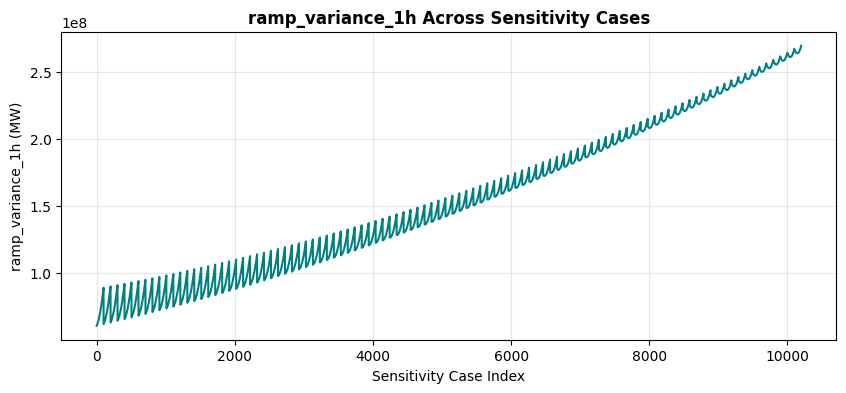

In [13]:

def plot_std_abs_ramp_1h(sens_df, var='std_abs_ramp_1h'):
    sens_df[var] = sens_df['risk'].apply(lambda risk: risk.get(var))

    ax = sens_df[var].plot(figsize=(10, 4), color='teal', linewidth=1.5)
    ax.set_title(f'{var} Across Sensitivity Cases', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sensitivity Case Index')
    ax.set_ylabel(f'{var} (MW)')
    ax.grid(alpha=0.3)

plot_std_abs_ramp_1h(sens_df, var='ramp_variance_1h')

In [14]:

def plot_3D(df, z_col):
    import plotly.express as px
    from pathlib import Path
    
    df[z_col] = df['risk'].apply(lambda risk: risk.get(z_col))

    x_col = "multiplier_soler" if "multiplier_soler" in df.columns else "multiplier_solar"
    y_col= "multiplier_wind"   

    fig = px.scatter_3d(
        df,
        x=x_col,
        y= y_col,
        z=df['risk'].apply(lambda risk: risk.get(z_col)),
        color=z_col,
        color_continuous_scale="Viridis",
        labels={
            x_col: "Solar Multiplier",
            "multiplier_wind": "Wind Multiplier",
            z_col: f"{z_col} (MW)",
        },
        title=f"3D Sensitivity: {z_col} vs Solar/Wind Multipliers",
        hover_data={x_col: True, "multiplier_wind": True, z_col: ":.2f"},
    )

    fig.update_traces(marker=dict(size=4, opacity=0.85))
    fig.update_layout(
        coloraxis_colorbar=dict(title=f"{z_col} (MW)"),
        margin=dict(l=0, r=0, b=0, t=40),
        width=850,
        height=650,
    )
    fig.show()
    
    # Save as static image for GitHub
    figures_dir = ROOT / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)
    
    img_path = figures_dir / f"3d_{z_col}.png"
    html_path = figures_dir / f"3d_{z_col}.html"
    
    fig.write_image(str(img_path), width=850, height=650)
    fig.write_html(str(html_path))
    
    print(f"Saved: {img_path.relative_to(ROOT)}")
    print(f"Saved: {html_path.relative_to(ROOT)}")
    
    return fig

plot_3D(sens_df, z_col='ramp_variance_1h')


Saved: figures\3d_ramp_variance_1h.png
Saved: figures\3d_ramp_variance_1h.html


In [11]:
plot_3D(sens_df, z_col='ramp_variance_3h')

c:\Users\xplv\AppData\Local\anaconda3\envs\mlrun_env\lib\site-packages\choreographer\utils\_tmpfile.py:137: TmpDirWarning: The temporary directory could not be deleted, execution will continue. errors: [(WindowsPath('C:/Users/xplv/AppData/Local/Temp/tmppde9rzp7/CrashpadMetrics-active.pma'), PermissionError(13, 'Access is denied')), (WindowsPath('C:/Users/xplv/AppData/Local/Temp/tmppde9rzp7'), OSError(41, 'The directory is not empty'))]
  warnings.warn(  # noqa: B028
Temporary dictory couldn't be removed manually.


Saved: figures\3d_ramp_variance_3h.png
Saved: figures\3d_ramp_variance_3h.html
